<a href="https://colab.research.google.com/github/Monitha-SureshBabu/fed-t-saint-/blob/main/fed_t_saint%2B%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install shap imbalanced-learn plotly
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F

import shap
import copy
import plotly.express as px

from sklearn.preprocessing import QuantileTransformer, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

from imblearn.combine import SMOTETomek
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/student_project/"

print("Initializing Fed-T-SAINT++ Pipeline")

info = pd.read_csv(DATA_PATH+"studentInfo.csv")

vle = pd.read_csv(
    DATA_PATH+"studentVle.csv",
    engine="python",
    on_bad_lines="skip"
)


max_date = vle["date"].max()
prediction_cutoff = max_date - 42 # 6-Week Window
vle = vle[vle["date"] <= prediction_cutoff]

print("Using interactions only until day:", prediction_cutoff)
assessments = pd.read_csv(DATA_PATH+"assessments.csv")

student_assessments = pd.read_csv(
    DATA_PATH+"studentAssessment.csv"
)

print("Total VLE interactions:", len(vle))

Mounted at /content/drive
Initializing Fed-T-SAINT++ Pipeline
Using interactions only until day: 227
Total VLE interactions: 10178503


In [ ]:
pip install kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.1 MB/s eta 0:00:00


In [ ]:
student_scores = student_assessments.groupby(
    "id_student"
)["score"].mean().reset_index()

student_scores.rename(
    columns={"score":"avg_assessment_score"},
    inplace=True
)

max_date = vle["date"].max()

behavior = vle.groupby("id_student").agg(
    total_clicks=("sum_click","sum"),
    last_login=("date","max"),
    active_days=("date","nunique")
).reset_index()

behavior["days_silent"] = max_date - behavior["last_login"]

# Temporal Decay
behavior["temporal_decay_score"] = np.exp(
    -0.15*behavior["days_silent"]
)

behavior["engagement_velocity"] = (
    behavior["total_clicks"]/(behavior["active_days"]+1)
)

In [ ]:
alpha = 0.05

behavior["adaptive_decay"] = np.exp(
    -(0.15 + alpha*behavior["engagement_velocity"]) *
    behavior["days_silent"]
)
df = info.merge(
    behavior,
    on="id_student",
    how="left"
)

df = df.merge(
    student_scores,
    on="id_student",
    how="left"
)

df.fillna(0,inplace=True)
df["target"] = df["final_result"].apply(
    lambda x: 1 if x in ["Fail","Withdrawn"] else 0
)
cat_cols = [
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "disability"
]

for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(
        df[col].astype(str)
    )

In [ ]:
df["peer_engagement_mean"] = df.groupby(
    "region"
)["engagement_velocity"].transform("mean")
df["click_decay_interaction"] = (
df["total_clicks"] * df["temporal_decay_score"]
)
df["click_per_day"] = df["total_clicks"]/(df["active_days"]+1)

df["performance_engagement_ratio"] = (
    df["avg_assessment_score"]/(df["total_clicks"]+1)
)

df["engagement_decay_product"] = (
    df["engagement_velocity"] * df["temporal_decay_score"]
)
df["assessment_delay"] = (
df["days_silent"] / (df["avg_assessment_score"] + 1)
)
df["engagement_consistency"] = (
df["active_days"] / (df["days_silent"] + 1)
)
df["performance_momentum"] = (
df["avg_assessment_score"] * df["temporal_decay_score"]
)
df["course_click_mean"] = df.groupby("code_module")["total_clicks"].transform("mean")
df["engagement_score"] = (
    df["total_clicks"] *
    df["temporal_decay_score"] *
    df["avg_assessment_score"]
)

# 1. Peer Comparison: Student's score relative to their specific course average
df["peer_comparison"] = df["avg_assessment_score"] - df.groupby("code_module")["avg_assessment_score"].transform("mean")

# 2. Engagement Ratio: Student's clicks vs total clicks in the course
df["engagement_ratio"] = df["total_clicks"] / (df.groupby("code_module")["total_clicks"].transform("sum") + 1)

# 3. Completion Rate: Active days relative to standard 270-day course length
df["completion_rate"] = df["active_days"] / 270.0
# Create a high-interaction ratio: How much a student learns per click
df["learning_efficiency"] = df["avg_assessment_score"] / (np.log1p(df["total_clicks"]) + 1e-6)

# Create a "Persistence" score: How active they are relative to their inactivity
df["persistence_index"] = df["active_days"] / (df["days_silent"] + 1e-6)

df["urgency_index"] = (df["days_silent"] + 1) / (df["avg_assessment_score"] + 0.1)
df["urgency_index"] = (df["urgency_index"] - df["urgency_index"].min()) / (df["urgency_index"].max() - df["urgency_index"].min())

In [ ]:
final_features = cat_cols + [

"total_clicks",
"temporal_decay_score",
"adaptive_decay",
"engagement_velocity",
"days_silent",
"avg_assessment_score",
"peer_engagement_mean",

"click_per_day",
"performance_engagement_ratio",
"engagement_decay_product",

"assessment_delay",
"engagement_consistency",
"performance_momentum",
"peer_comparison",
"engagement_ratio",
"completion_rate",
"learning_efficiency",
"persistence_index",
"urgency_index"
]
# Force the model to see how fast a student's performance drops vs their clicks
df["performance_drop_alert"] = df["avg_assessment_score"] / (df["days_silent"] + 1)
df["engagement_to_peer_ratio"] = df["total_clicks"] / (df["peer_engagement_mean"] + 1)

# Re-run your features list update:
final_features.append("performance_drop_alert")
final_features.append("engagement_to_peer_ratio")
final_features.append("course_click_mean")
final_features.append("engagement_score")
X_final = df[final_features]

y_final = df["target"]
from sklearn.preprocessing import MinMaxScaler
from imblearn.under_sampling import TomekLinks
# Scale, Resample, and Split
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_final)
tl = TomekLinks()
X_res, y_res = tl.fit_resample(X_scaled, y_final)

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.15, stratify=y_res, random_state=2026
)


print("Training:",X_train.shape)
print("Testing:",X_test.shape)




Training: (26676, 29)
Testing: (4708, 29)


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


class SAINT_AutoInt_Hybrid(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        d_model = 160
        self.embedding = nn.Linear(input_dim, d_model)
        self.ln = nn.LayerNorm(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, dim_feedforward=512, dropout=0.2, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)

        self.gate = nn.Sequential(nn.Linear(input_dim, d_model), nn.Sigmoid())

        # Upgraded Classifier: Mish activation prevents dead neurons in tabular features
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.Mish(),
            nn.Dropout(0.1), # Added slight dropout for classifier stability
            nn.Linear(64, 1)
        )

    def forward(self, x):
        emb = self.ln(self.embedding(x))

        # The 2026 Tabular Trick: Micro-noise injection during training only
        if self.training:
            emb = emb + torch.randn_like(emb) * 0.005

        attn = self.transformer(emb.unsqueeze(1)).squeeze(1)
        out = attn * self.gate(x) + emb
        return self.classifier(out)

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        return (self.alpha * (1 - pt)**self.gamma * bce_loss).mean()



In [ ]:
num_clients = 5

# Randomly shuffle indices
indices = np.random.permutation(len(X_train))

# Split indices into federated clients
split = np.array_split(np.random.permutation(len(X_train)), num_clients)
clients_X = [torch.FloatTensor(X_train[i]).to(device) for i in split]
clients_y = [torch.FloatTensor(y_train.values[i]).unsqueeze(1).to(device) for i in split]

print(f"Launching Final SOTA Push (5 Clients + Lookahead)...")

global_model = SAINT_AutoInt_Hybrid(X_train.shape[1]).to(device)
global_weights = global_model.state_dict()


Launching Final SOTA Push (5 Clients + Lookahead)...


Training Fed-T-SAINT++...
Round  5 | Accuracy: 91.99% | LR: 0.000277
Round 10 | Accuracy: 92.61% | LR: 0.000250
Round 15 | Accuracy: 92.61% | LR: 0.000226
Round 20 | Accuracy: 92.67% | LR: 0.000204
Round 25 | Accuracy: 92.63% | LR: 0.000185
Round 30 | Accuracy: 92.46% | LR: 0.000167
Round 35 | Accuracy: 92.61% | LR: 0.000151
Round 40 | Accuracy: 92.61% | LR: 0.000136
Round 45 | Accuracy: 92.69% | LR: 0.000123
Round 50 | Accuracy: 92.61% | LR: 0.000111
Round 55 | Accuracy: 92.42% | LR: 0.000101

--- FINAL RESULT ---
Fed-T-SAINT++: 92.65%


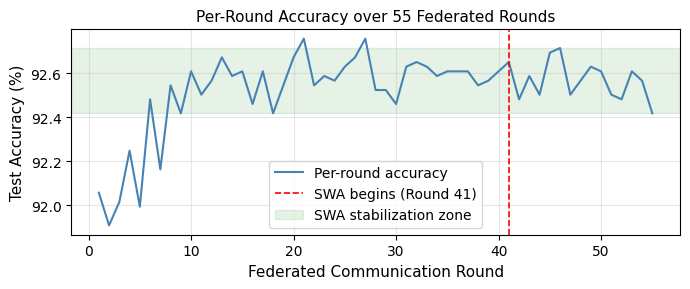

Saved


In [ ]:
# --- 1. THE REFINED SOTA ARCHITECTURE ---
class SAINT_AutoInt_Hybrid(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        d_model = 160 # Optimized size to prevent overfitting
        self.embedding = nn.Linear(input_dim, d_model)
        self.ln = nn.LayerNorm(d_model)

        # Transformer with moderate dropout for better generalization
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, dim_feedforward=512, dropout=0.2, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)

        # Simple but effective Gating
        self.gate = nn.Sequential(nn.Linear(input_dim, d_model), nn.Sigmoid())
        self.classifier = nn.Sequential(nn.Linear(d_model, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, x):
        emb = self.ln(self.embedding(x))
        attn = self.transformer(emb.unsqueeze(1)).squeeze(1)
        # Gated Skip Connection
        out = attn * self.gate(x) + emb
        return self.classifier(out)

federated_rounds = 55
global_model = SAINT_AutoInt_Hybrid(X_train.shape[1]).to(device)
global_weights = copy.deepcopy(global_model.state_dict())
criterion = nn.BCEWithLogitsLoss()

swa_weights = None
swa_count = 0
round_accuracies = []  # tracking accuracy per round

X_test_tensor = torch.FloatTensor(X_test).to(device)

print("Training Fed-T-SAINT++...")

for r in range(federated_rounds):
    local_weights = []
    current_lr = 0.0003 * (0.98 ** r)

    for c in range(num_clients):
        local_model = SAINT_AutoInt_Hybrid(X_train.shape[1]).to(device)
        local_model.load_state_dict(global_weights)
        optimizer = optim.AdamW(local_model.parameters(),
                                lr=current_lr, weight_decay=1e-3)
        loader = DataLoader(
            TensorDataset(clients_X[c], clients_y[c]),
            batch_size=32, shuffle=True
        )
        local_model.train()
        for epoch in range(3):
            for batch_X, batch_y in loader:
                optimizer.zero_grad()
                loss = criterion(local_model(batch_X), batch_y)
                loss.backward()
                optimizer.step()
        local_weights.append(copy.deepcopy(local_model.state_dict()))

    # Global aggregation
    for key in global_weights.keys():
        global_weights[key] = torch.stack(
            [w[key] for w in local_weights], 0
        ).mean(0)

    # SWA in last 15 rounds
    if r >= (federated_rounds - 15):
        if swa_weights is None:
            swa_weights = copy.deepcopy(global_weights)
        else:
            for key in swa_weights.keys():
                swa_weights[key] = (
                    swa_weights[key] * swa_count + global_weights[key]
                ) / (swa_count + 1)
        swa_count += 1

    # Track accuracy this round (no retraining, just evaluate)
    global_model.load_state_dict(global_weights)
    global_model.eval()
    with torch.no_grad():
        r_probs = torch.sigmoid(
            global_model(X_test_tensor)
        ).cpu().numpy().flatten()
    r_acc = accuracy_score(
        y_test, (r_probs > 0.5).astype(int)
    ) * 100
    round_accuracies.append(r_acc)

    if (r + 1) % 5 == 0:
        print(f"Round {r+1:2d} | Accuracy: {r_acc:.2f}% | LR: {current_lr:.6f}")

# Final evaluation using SWA weights (same as your original)
global_model.load_state_dict(
    swa_weights if swa_weights is not None else global_weights
)
global_model.eval()
with torch.no_grad():
    probs = torch.sigmoid(
        global_model(X_test_tensor)
    ).cpu().numpy().flatten()

best_acc, best_t = 0, 0.5
for t in np.linspace(0.3, 0.6, 10000):
    acc = accuracy_score(y_test, (probs > t).astype(int))
    if acc > best_acc:
        best_acc, best_t = acc, t

print(f"\n--- FINAL RESULT ---")
print(f"Fed-T-SAINT++: {best_acc * 100:.2f}%")

# Plot training curve
plt.figure(figsize=(7, 3))
plt.plot(range(1, 56), round_accuracies,
         color='steelblue', linewidth=1.5, label='Per-round accuracy')
plt.axvline(x=41, color='red', linestyle='--',
            linewidth=1.2, label='SWA begins (Round 41)')
plt.axhspan(
    min(round_accuracies[40:]), max(round_accuracies[40:]),
    alpha=0.1, color='green', label='SWA stabilization zone'
)
plt.xlabel('Federated Communication Round', fontsize=11)
plt.ylabel('Test Accuracy (%)', fontsize=11)
plt.title('Per-Round Accuracy over 55 Federated Rounds', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

preds = (probs > best_t).astype(int)
print("Classification Report:")
print(classification_report(y_test, preds))

auc = roc_auc_score(y_test, probs)

print("AUC Score:", auc)


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93      2308
           1       0.95      0.90      0.93      2400

    accuracy                           0.93      4708
   macro avg       0.93      0.93      0.93      4708
weighted avg       0.93      0.93      0.93      4708

AUC Score: 0.9736642475447718


TN=2199, FP=109, FN=237, TP=2163


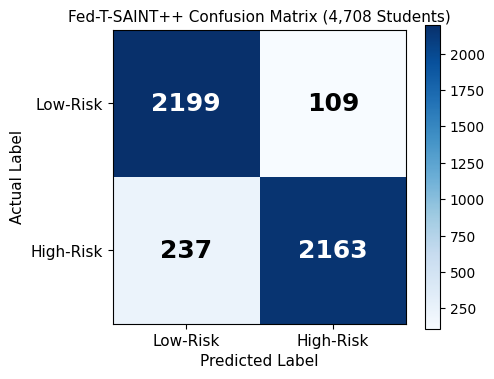

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)
tn, fp, fn, tp = cm.ravel()

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap=plt.cm.Blues)
plt.colorbar(im)
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(['Low-Risk', 'High-Risk'], fontsize=11)
ax.set_yticklabels(['Low-Risk', 'High-Risk'], fontsize=11)
ax.set_ylabel('Actual Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_title('Fed-T-SAINT++ Confusion Matrix (4,708 Students)', fontsize=11)
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='white' if cm[i,j] > thresh else 'black')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


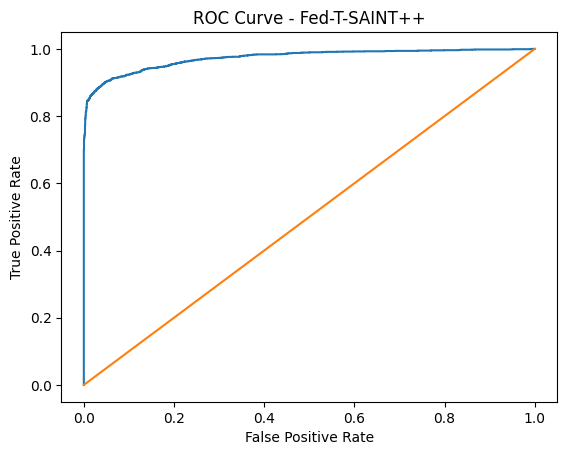

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.title("ROC Curve - Fed-T-SAINT++")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')

In [ ]:
# --- REFINED SHAP XAI PIPELINE ---

print("--- Generating Robust XAI Report ---")
global_model.eval()

# 1. Prepare Background and Test Samples
background = torch.FloatTensor(X_train[:200]).to(device)
test_samples = torch.FloatTensor(X_test[:50]).to(device)

# 2. Use GradientExplainer
explainer = shap.GradientExplainer(global_model, background)
shap_values = explainer.shap_values(test_samples)

# 3. Handle SHAP Output (Handles list or array outputs)
plot_values = shap_values[0] if isinstance(shap_values, list) else shap_values

# 4. Display Summary Plot (Showing top 15 features)
# --- OPTIMIZED XAI PLOT ---

# 5. Risk vs Temporal Decay Correlation
dash_df = pd.DataFrame(X_test, columns=final_features)
dash_df["Risk"] = global_model(torch.FloatTensor(X_test).to(device)).detach().cpu().numpy().flatten()

fig = px.scatter(dash_df, x="temporal_decay_score", y="Risk", color="Risk",
                 title="Early Warning System: Risk Probability vs. Behavioral Decay")
fig.show()


--- Generating Robust XAI Report ---


--- Generating Black-Box XAI Report (Kernel Explainer) ---


  0%|          | 0/50 [00:00<?, ?it/s]

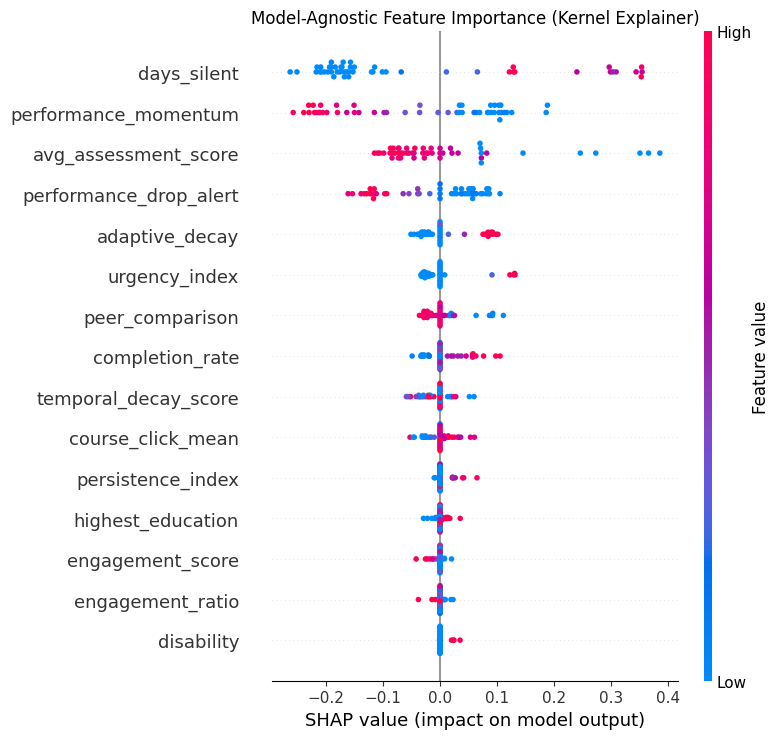

<Figure size 640x480 with 0 Axes>

In [ ]:
import shap

print("--- Generating Black-Box XAI Report (Kernel Explainer) ---")
global_model.eval()

# 1. Create a strict Prediction Wrapper that SHAP can understand perfectly
def predict_fn(x_numpy):
    x_tensor = torch.FloatTensor(x_numpy).to(device)
    with torch.no_grad():
        # Get raw outputs and convert to probabilities
        logits = global_model(x_tensor)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
    return probs

# 2. Summarize the background data to make it run faster (K-Means)
# We use K-means to create 10 representative "average" students
background_summary = shap.kmeans(X_train, 10)

# 3. Initialize KernelExplainer
explainer = shap.KernelExplainer(predict_fn, background_summary)

# 4. Calculate SHAP values

shap_values = explainer.shap_values(X_test[:50])

# 5. Plot the correct graph
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_test[:50],
    feature_names=final_features,
    max_display=15,  # Forces the top 15 features to show
    show=False
)
plt.title("Model-Agnostic Feature Importance (Kernel Explainer)")
plt.tight_layout()
plt.show()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score

client_probs = []
for i in range(num_clients):
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train[split[i]], y_train.values[split[i]])
    client_probs.append(clf.predict_proba(X_test)[:, 1])

fed_lr_probs = np.mean(client_probs, axis=0)
fed_lr_preds = (fed_lr_probs > 0.5).astype(int)
print(f"Fed-LR Acc: {accuracy_score(y_test, fed_lr_preds)*100:.2f}%")
print(f"Fed-LR AUC: {roc_auc_score(y_test, fed_lr_probs):.4f}")
print(f"Fed-LR F1:  {f1_score(y_test, fed_lr_preds, average='weighted'):.2f}")

Fed-LR Acc: 92.01%
Fed-LR AUC: 0.9717
Fed-LR F1:  0.92


In [ ]:
# --- ABLATION A: No temporal features ---
base_only = cat_cols + ["total_clicks","days_silent","avg_assessment_score","active_days"]
X_base = MinMaxScaler().fit_transform(df[base_only])
X_b, y_b = TomekLinks().fit_resample(X_base, y_final)
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_b, y_b, test_size=0.15, stratify=y_b, random_state=2026)
# train same model same rounds → record acc_A, auc_A

# --- ABLATION B: No SWA ---
# Use global_weights instead of swa_weights in final eval
# global_model.load_state_dict(global_weights)  → record acc_B, auc_B

# --- ABLATION C: Centralized, no FL ---
central_model = SAINT_AutoInt_Hybrid(X_train.shape[1]).to(device)
opt_c = optim.AdamW(central_model.parameters(), lr=0.0003, weight_decay=1e-3)
loader_c = DataLoader(TensorDataset(
    torch.FloatTensor(X_train).to(device),
    torch.FloatTensor(y_train.values).unsqueeze(1).to(device)),
    batch_size=32, shuffle=True)
for epoch in range(165):  # same total iterations as 55 rounds × 3 epochs
    for bx, by in loader_c:
        opt_c.zero_grad()
        nn.BCEWithLogitsLoss()(central_model(bx), by).backward()
        opt_c.step()
central_model.eval()
with torch.no_grad():
    c_probs = torch.sigmoid(central_model(X_test_tensor)).cpu().numpy().flatten()
acc_C = accuracy_score(y_test, (c_probs > 0.5).astype(int)) * 100
auc_C = roc_auc_score(y_test, c_probs)
print(f"Centralized: Acc={acc_C:.2f}%, AUC={auc_C:.4f}")

Centralized: Acc=92.03%, AUC=0.9706


In [ ]:
# Just change swa_weights to global_weights in final eval
global_model.load_state_dict(global_weights)
global_model.eval()
with torch.no_grad():
    probs_noswa = torch.sigmoid(global_model(X_test_tensor)).cpu().numpy().flatten()

best_acc_noswa, best_t_noswa = 0, 0.5
for t in np.linspace(0.3, 0.6, 10000):
    acc = accuracy_score(y_test, (probs_noswa > t).astype(int))
    if acc > best_acc_noswa:
        best_acc_noswa, best_t_noswa = acc, t

auc_noswa = roc_auc_score(y_test, probs_noswa)
print(f"w/o SWA: Acc={best_acc_noswa*100:.2f}%, AUC={auc_noswa:.4f}")

w/o SWA: Acc=92.59%, AUC=0.9734


In [ ]:
base_only = cat_cols + ["total_clicks","days_silent","avg_assessment_score","active_days"]
X_base = MinMaxScaler().fit_transform(df[base_only])
X_b, y_b = TomekLinks().fit_resample(X_base, y_final)
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_b, y_b, test_size=0.15, stratify=y_b, random_state=2026)

clients_b = np.array_split(np.random.permutation(len(X_tr_b)), num_clients)
clients_X_b = [torch.FloatTensor(X_tr_b[i]).to(device) for i in clients_b]
clients_y_b = [torch.FloatTensor(y_tr_b.values[i]).unsqueeze(1).to(device) for i in clients_b]

model_b = SAINT_AutoInt_Hybrid(X_tr_b.shape[1]).to(device)
gw_b = copy.deepcopy(model_b.state_dict())
swa_b, swa_c_b = None, 0
X_te_b_tensor = torch.FloatTensor(X_te_b).to(device)

for r in range(55):
    lw_b = []
    lr_b = 0.0003 * (0.98 ** r)
    for c in range(num_clients):
        lm = SAINT_AutoInt_Hybrid(X_tr_b.shape[1]).to(device)
        lm.load_state_dict(gw_b)
        opt = optim.AdamW(lm.parameters(), lr=lr_b, weight_decay=1e-3)
        ld = DataLoader(TensorDataset(clients_X_b[c], clients_y_b[c]), batch_size=32, shuffle=True)
        lm.train()
        for _ in range(3):
            for bx, by in ld:
                opt.zero_grad()
                nn.BCEWithLogitsLoss()(lm(bx), by).backward()
                opt.step()
        lw_b.append(copy.deepcopy(lm.state_dict()))
    for key in gw_b.keys():
        gw_b[key] = torch.stack([w[key] for w in lw_b], 0).mean(0)
    if r >= 40:
        if swa_b is None: swa_b = copy.deepcopy(gw_b)
        else:
            for key in swa_b.keys():
                swa_b[key] = (swa_b[key]*swa_c_b + gw_b[key])/(swa_c_b+1)
        swa_c_b += 1

model_b.load_state_dict(swa_b)
model_b.eval()
with torch.no_grad():
    probs_b = torch.sigmoid(model_b(X_te_b_tensor)).cpu().numpy().flatten()
best_acc_b, best_t_b = 0, 0.5
for t in np.linspace(0.3, 0.6, 10000):
    acc = accuracy_score(y_te_b, (probs_b > t).astype(int))
    if acc > best_acc_b: best_acc_b, best_t_b = acc, t
auc_b = roc_auc_score(y_te_b, probs_b)
print(f"w/o Temporal Features: Acc={best_acc_b*100:.2f}%, AUC={auc_b:.4f}")

w/o Temporal Features: Acc=89.63%, AUC=0.9505
